You are a data analyst working for a tech company closely monitoring the AI tools market. You want to understand the evolving popularity of three major AI tools, ChatGPT, Gemini, and Microsoft Copilot, and identify which tool is gaining the most traction and how they compare over time.


<img src="ai_tools.jpg" align="center"/>

You'll work with real-world time series data that captures the global interest in these tools over several weeks. Your goal is to analyze this data, uncover patterns, and provide actionable insights to help your company make informed decisions. This might include determining where to focus marketing efforts, predicting future trends, or identifying potential areas for improvement.

Are you ready to help your company stay ahead of the curve in the competitive AI tools market? Let's get started!

### The Data

The Google Trends data is available as a CSV file `ai_tools_comparison.csv`.
The data contains the number of worldwide searches for chatGpt, Gemini, and Microsoft Copilot over the past 12 months as of September 2024. 
<!--- Link to query: https://trends.google.com/trends/explore?q=chatgpt,gemini,%2Fg%2F11tsqm45vd&hl=en-US -->

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
trends = pd.read_csv('ai_tools_comparison.csv')

# Inspect the data
trends.head()

,week,chatgpt,gemini,microsoft_copilot
0,2023-08-27,56,3,1
1,2023-09-03,56,3,1
2,2023-09-10,63,3,1
3,2023-09-17,64,3,1
4,2023-09-24,66,3,1


In [ ]:
trends['week'] = pd.to_datetime(trends['week'])

trends.set_index('week', inplace=True)

# Inspect the result to confirm the Index is now a DatetimeIndex
print(trends.info())
print(trends.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 54 entries, 2023-08-27 to 2024-09-01
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   chatgpt            54 non-null     int64
 1   gemini             54 non-null     int64
 2   microsoft_copilot  54 non-null     int64
dtypes: int64(3)
memory usage: 1.7 KB
None
            chatgpt  gemini  microsoft_copilot
week                                          
2023-08-27       56       3                  1
2023-09-03       56       3                  1
2023-09-10       63       3                  1
2023-09-17       64       3                  1
2023-09-24       66       3                  1


In [ ]:
growth_rates = trends.pct_change().fillna(0).mul(100)

std_devs = growth_rates.std().sort_values()

most_consistent_tool = std_devs.index[0]

print("Standard Deviation of Growth Rates (Sorted):")
print(std_devs)
print(f"\nThe most consistent tool is: {most_consistent_tool}")

Standard Deviation of Growth Rates (Sorted):
chatgpt               8.966296
microsoft_copilot    24.338599
gemini               36.025774
dtype: float64

The most consistent tool is: chatgpt


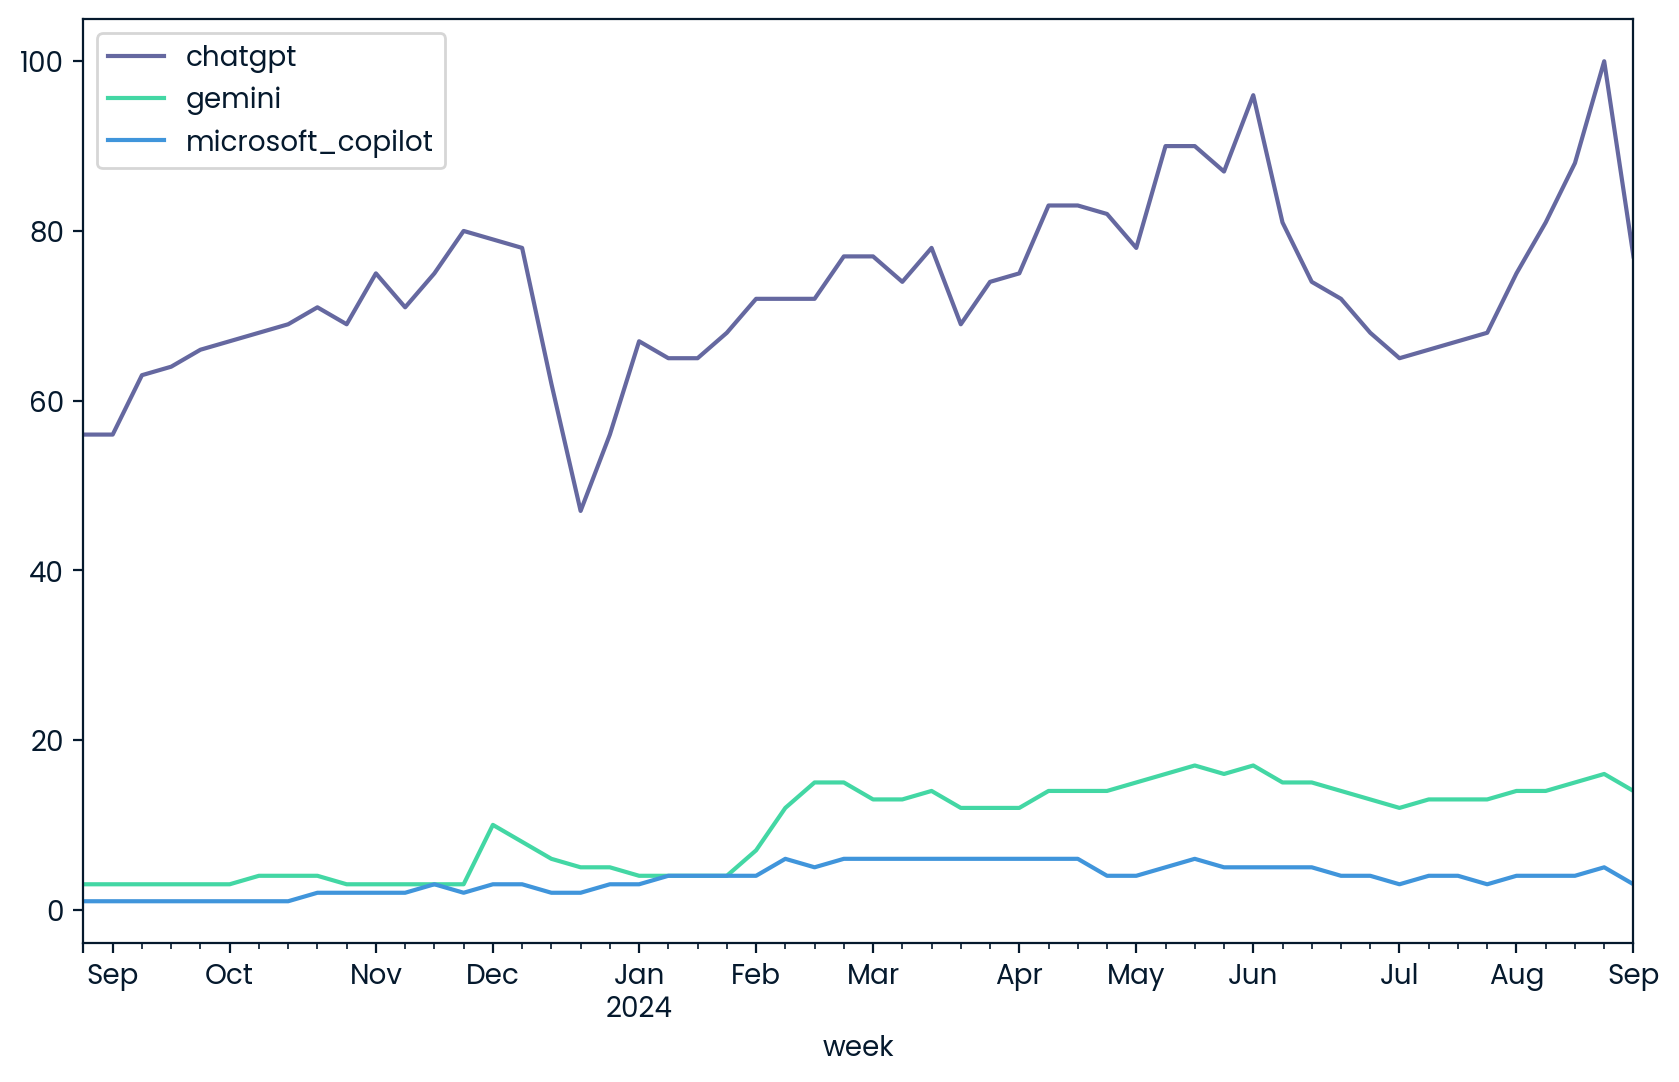

In [26]:
trends_copy = trends.copy()
trends_copy.plot(figsize=(10,6))
plt.show()


In [27]:
gpt_dip = "December 2023"

In [ ]:
monthly_data = trends.resample('M').mean()

monthly_averages = monthly_data.mean(axis=1)

sorted_months = monthly_averages.sort_values(ascending=False)

best_month = sorted_months.index[0].month_name()

print(f"The month with the highest overall search interest is: {best_month}")
print("\nMonthly Interest Averages (Sorted):")
print(sorted_months)

The month with the highest overall search interest is: May

Monthly Interest Averages (Sorted):
week
2024-05-31    35.750000
2024-08-31    35.000000
2024-04-30    33.250000
2024-06-30    32.533333
2024-09-30    31.333333
2024-03-31    31.066667
2024-02-29    30.250000
2024-07-31    27.583333
2023-11-30    26.833333
2024-01-31    24.666667
2023-10-31    24.600000
2023-12-31    24.600000
2023-09-30    22.083333
2023-08-31    20.000000
dtype: float64
